# Disease Prediction Model

**Objective**: Predict whether the patient has the disease or not.

**Dataset**: Cleveland dataset (UCI Machine Learning Repository) - 303 patients, 14 features, binary target (Healthy / Disease).

**Approach**: Logistic Regression, Decision Trees and Random Forest, compared on Precision, Recall, F1-score and ROC-AUC.

## 1. Load the data

Importing all the necessary libraries. Exploring the data, looking at what we're going to work with.

In [183]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns', None)

columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num' 
]

 
df = pd.read_csv('processed.cleveland.data', header = None, names = columns, na_values='?')
df['num'] = df['num'].apply(lambda x:1 if x>0 else 0)


**Note:** So I kind of ran into a problem. I was mapping the diagnosis to 0 and 1 using the following format:
 **df['num'] = df['num'].map({1:0, 2:1})**
 But, it turns out values other than 1 and 0 will be declared NaN (Not a Number). As the dataset diagnosis according to severity (0-4), I've used apply() to resolve this issue for now. In the future, maybe I will also display the severity as well, but for now just the yes or no diagnosis is fine.
 **df['num'] = df['num'].map({
    0: 0,
    1: 1,
    2: 1,
    3: 1,
    4: 1
})** it can also be done this way.


Another thing, **na_values='?'** prevents '?' strings in columns that cannot be converted into numerical values. It helps when you compute correlation on columns.

## 2. Exploratory Data Analysis



In [184]:
display(df.head())
display(Markdown("<br>**Dataset Info:**"))
print(df.info())


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


<br>**Dataset Info:**

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None


In [185]:
print(df['num'].value_counts())

num
0    164
1    139
Name: count, dtype: int64


In [186]:
df['num'].value_counts(normalize=True).rename({0:'Healthy', 1:'Disease'})

num
Healthy    0.541254
Disease    0.458746
Name: proportion, dtype: float64

In [187]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


**Note**: There are 6 null values in this dataset(4 in **ca**, 2 in **thal**). We will take care of this by using scikit-learn's **SimpleImputer** later.

**Checking class imbalance**

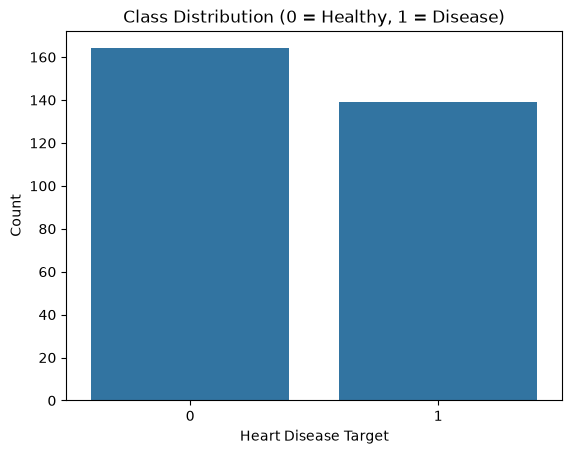

In [188]:
sns.countplot(x='num', data=df)
plt.title('Class Distribution (0 = Healthy, 1 = Disease)')
plt.xlabel('Heart Disease Target')
plt.ylabel('Count')
plt.show()

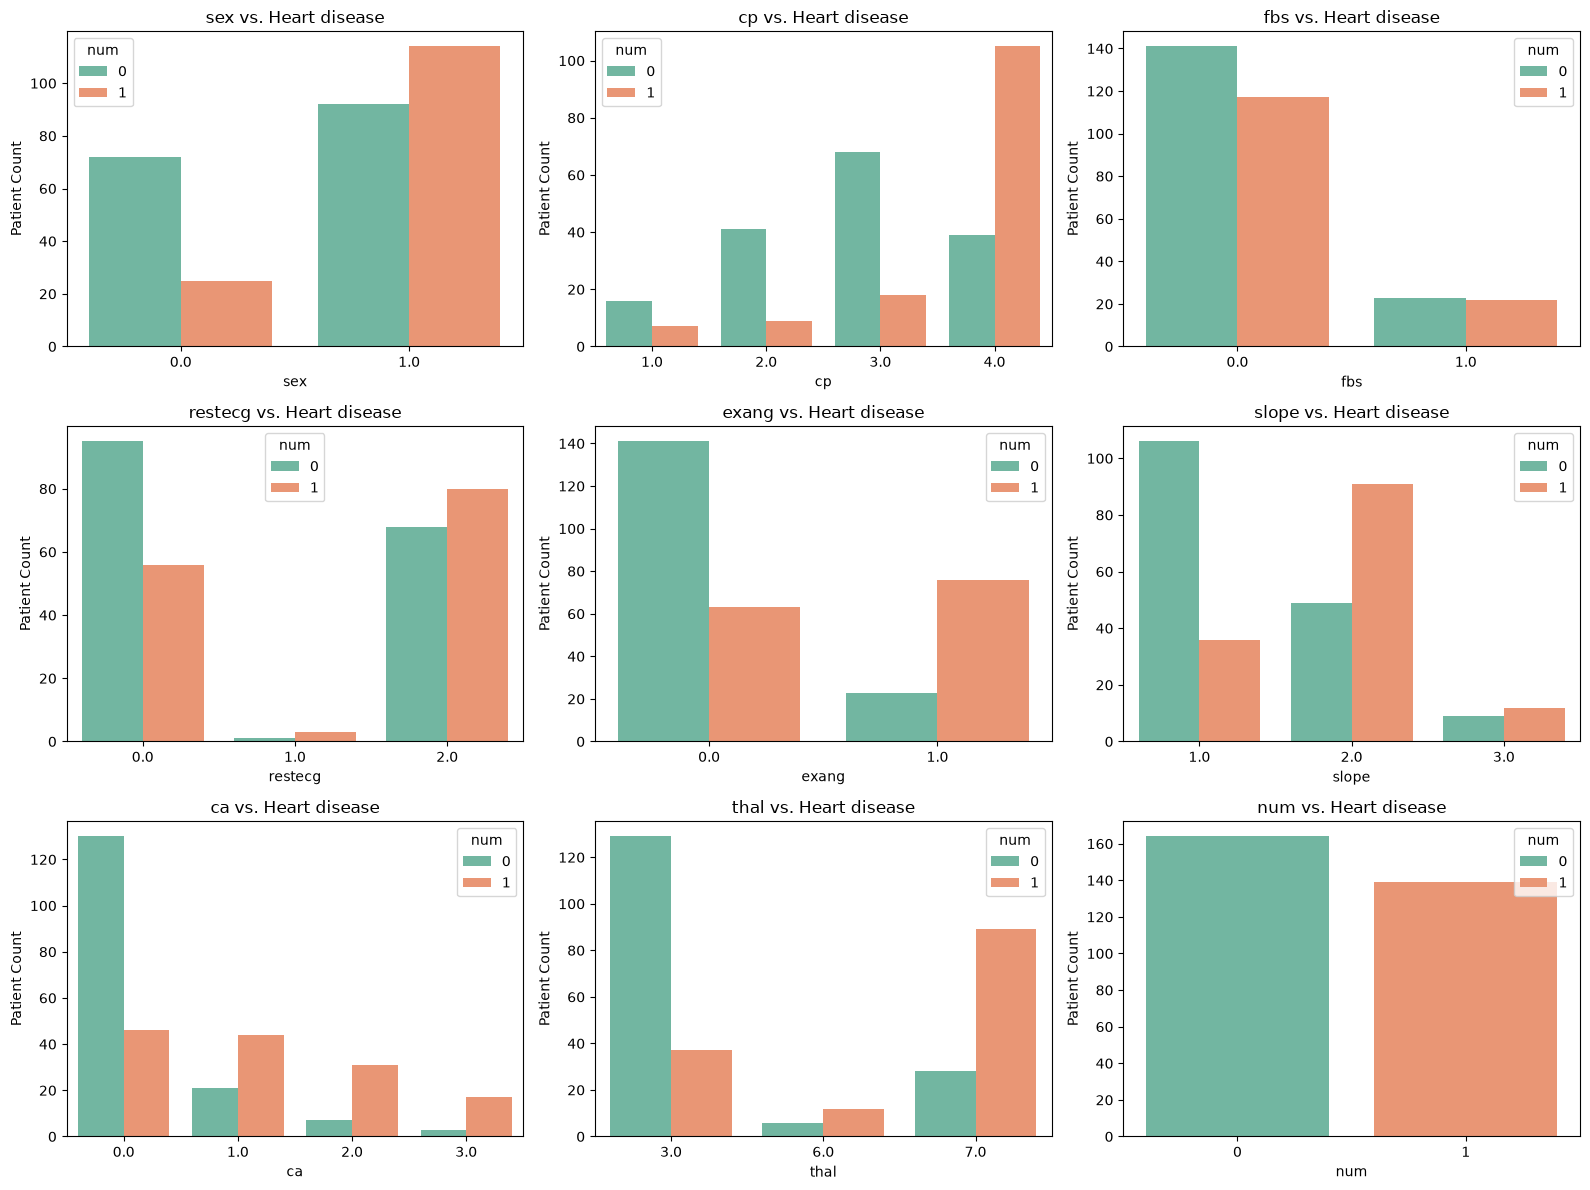

In [189]:
discrete_cols = [col for col in df.columns if df[col].nunique() < 15]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, col in zip(axes.flatten(), discrete_cols):
    sns.countplot(data=df, x=col, hue='num', ax=ax, palette='Set2')
    ax.set_title(f'{col} vs. Heart disease')
    ax.set_xlabel(col)
    ax.set_ylabel(f'Patient Count')



plt.tight_layout()
plt.show()

In [190]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    unique_vals = df[col].nunique()
    print(f'Feature: {col:<12} | Unique values: {unique_vals:<4} | Type: {'Continuous' if unique_vals>15 else 'Discrete'}')

Feature: age          | Unique values: 41   | Type: Continuous
Feature: sex          | Unique values: 2    | Type: Discrete
Feature: cp           | Unique values: 4    | Type: Discrete
Feature: trestbps     | Unique values: 50   | Type: Continuous
Feature: chol         | Unique values: 152  | Type: Continuous
Feature: fbs          | Unique values: 2    | Type: Discrete
Feature: restecg      | Unique values: 3    | Type: Discrete
Feature: thalach      | Unique values: 91   | Type: Continuous
Feature: exang        | Unique values: 2    | Type: Discrete
Feature: oldpeak      | Unique values: 40   | Type: Continuous
Feature: slope        | Unique values: 3    | Type: Discrete
Feature: ca           | Unique values: 4    | Type: Discrete
Feature: thal         | Unique values: 3    | Type: Discrete
Feature: num          | Unique values: 2    | Type: Discrete


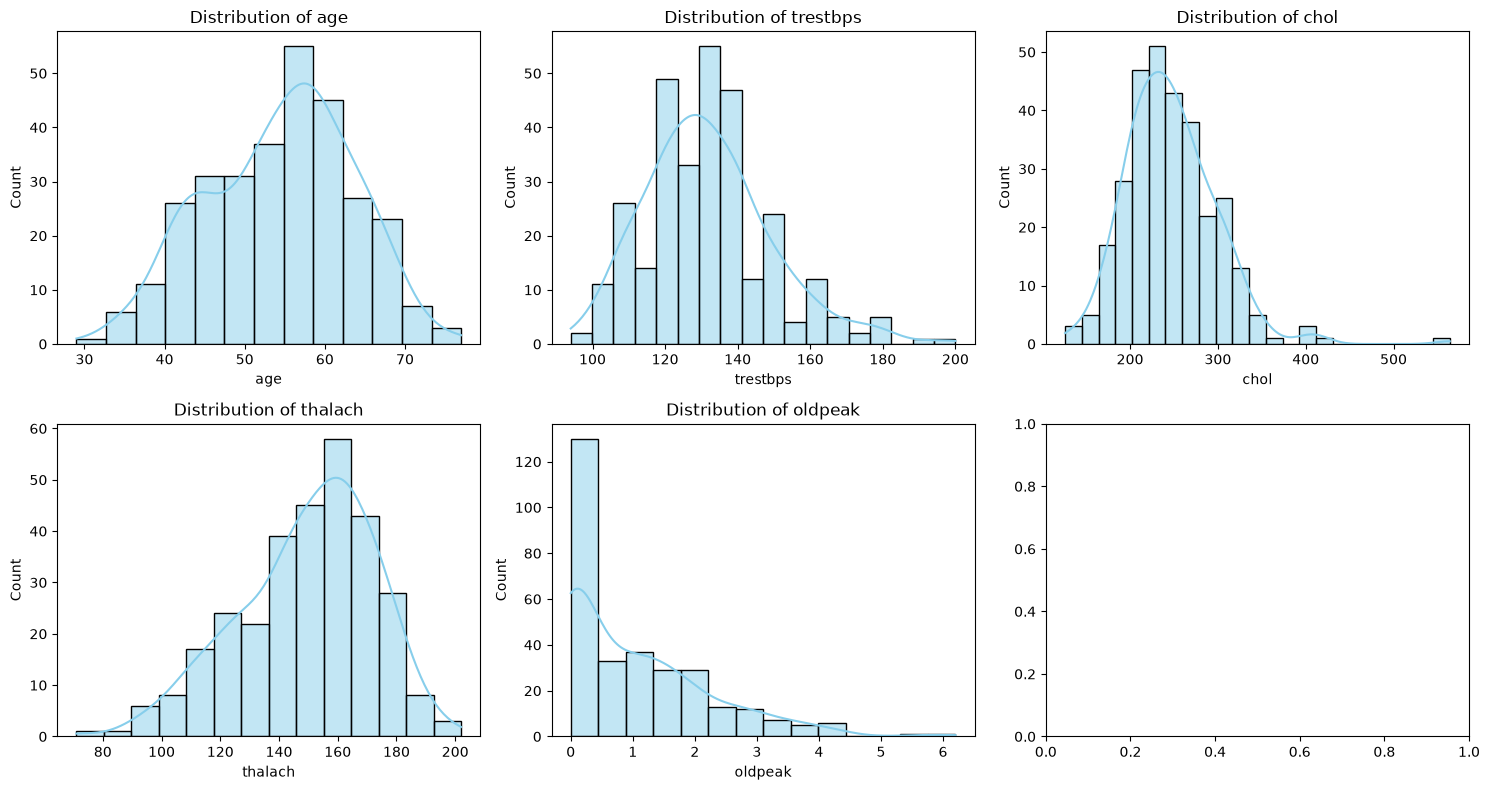

In [191]:
fig, axis = plt.subplots(2, 3, figsize=(15, 8))
num_features = ['age','trestbps','chol', 'thalach', 'oldpeak']

for ax, feature in zip(axis.flatten(), num_features):
    sns.histplot(df[feature], kde=True, ax=ax, color='skyblue')
    ax.set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

**Note:** I chose these specific features because they are continous (age can be 55.5, cholesterol could be 245 mg/dl, ST depression could be 1.5).
Columns like sex, fbs etc. are discrete (0 or 1) and require bar charts.

**age** is pretty symmetrical and will require just StandardScaler.

**trestbps** is slightly right-skewed. We'll see what do with it.

**chol** is right-skewed with extreme outlier, will require RobustScaler first.

**thalach** is mildly skewed, will only need StandardScaler.

**oldpeak** is heavily right-skewed, will require Log1p Transformation first.

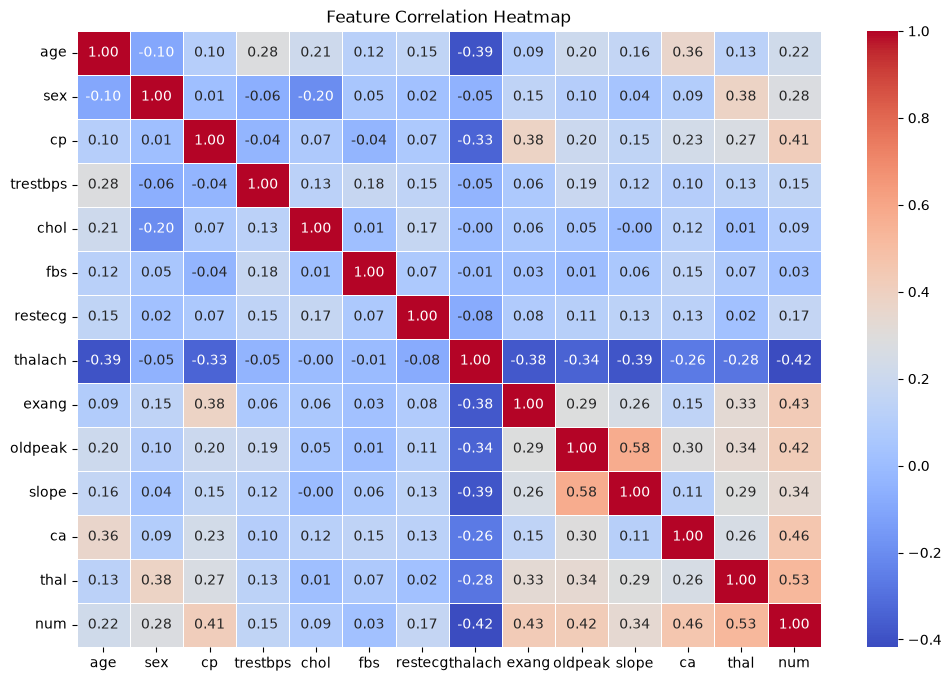

In [192]:
plt.figure(figsize=(12, 8))
corr = df.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidth=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

**_Top Positive Predictors:_**
**thal**(Thalassemia) and **ca**(number of major vessels colored by fluoroscopy) have the most positive correlation with heart-disease likelihood.

**exang**(Exercise-induced angina), **cp**(chest pain Type) and **oldpeak**(ST depression) have solid positive correlations as well.

**sex** has moderate positive correlation.

**_Top Negative Predictors:_**
**thalach**(Maximum heart-rate achieved) has the most negative correlation.

**_Irrelevant Features:_**
**fbs**(Fasting blood sugar), **chol**(Cholesterol) show virtually zero correlation with num.

**Checking for Multicollinearity:-**

**slope** and **oldpeak** have the highest inter-feature correlation in the dataset(0.58). Still it is less than 0.70, so no features need to be dropped.

**thalach** and **age**, **slope** have the lowest inter-feature correlation(-0.39). Again, we do not go below -0.70, so we're good.

## 3. Preprocess the data

In [193]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from scipy.stats import skew

X = df.drop(columns=['num'])
y = df['num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

passthrough_cols = [
    col for col in cat_cols if X_train[col].nunique() == 2
]

nominal_cols = [
    col for col in cat_cols if X_train[col].nunique() > 2
]

standard_cols=[]
robust_cols=[]

for col in num_features:
    col_skew = abs(skew(X_train[col].dropna()))
    if col_skew > 0.75:
        robust_cols.append(col)
    else:
        standard_cols.append(col)

# Defining Pipelines
std_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

rob_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer (
    transformers=[
        ('std_num', std_pipeline, standard_cols),
        ('rob_num', rob_pipeline, robust_cols),
        ('cat', cat_pipeline, nominal_cols),
        ('pass', 'passthrough', passthrough_cols)
    ]
)

# Scaling
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

all_features = preprocessor.get_feature_names_out()

X_train_final = pd.DataFrame(X_train_scaled, columns=all_features, index=X_train.index)
X_test_final = pd.DataFrame(X_test_scaled, columns=all_features, index=X_test.index)

display(Markdown('**Preprocessing complete!**'))
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

**Preprocessing complete!**

X_train shape: (242, 13)
X_test shape: (61, 13)


## 4. Train the models

In [194]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models ={
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42)
}

display(Markdown('**5-Fold Cross Validation Results (ROC-AUC)**'))

for name, model in models.items():
    cv_pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', model)])

    cv_scores = cross_val_score(
        cv_pipeline, X, y, cv=skf, scoring='roc_auc', n_jobs=1
    )

    display(Markdown(f"<br>**{name}**"))
    display(Markdown(f'Fold scores: {np.round(cv_scores, 4)}'))
    display(Markdown(f'Mean ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})'))


results_list = []
predictions = {}

for name, model in models.items():
    model.fit(X_train_final, y_train)

    y_pred = model.predict(X_test_final)
    y_proba = model.predict_proba(X_test_final)[:, 1]

    predictions[name] = y_pred

    results_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
        
    })
    display(Markdown(f'<br>**Model Trained:** {name}'))


results_df = pd.DataFrame(results_list)

**5-Fold Cross Validation Results (ROC-AUC)**

<br>**Logistic Regression**

Fold scores: [0.9535 0.8983 0.9026 0.9057 0.9275]

Mean ROC-AUC: 0.9175 (+/- 0.0206)

<br>**Decision Tree**

...

Fold scores: [0.9232 0.8788 0.869  0.9029 0.9269]

Mean ROC-AUC: 0.9002 (+/- 0.0231)

<br>**Model Trained:** Logistic Regression

<br>**Model Trained:** Decision Tree

<br>**Model Trained:** Random Forest

**Note:** Theoretically, Logistic Regression is the best model for this dataset. It wins with a Mean ROC-AUC of 92%

## 5. Evaluation

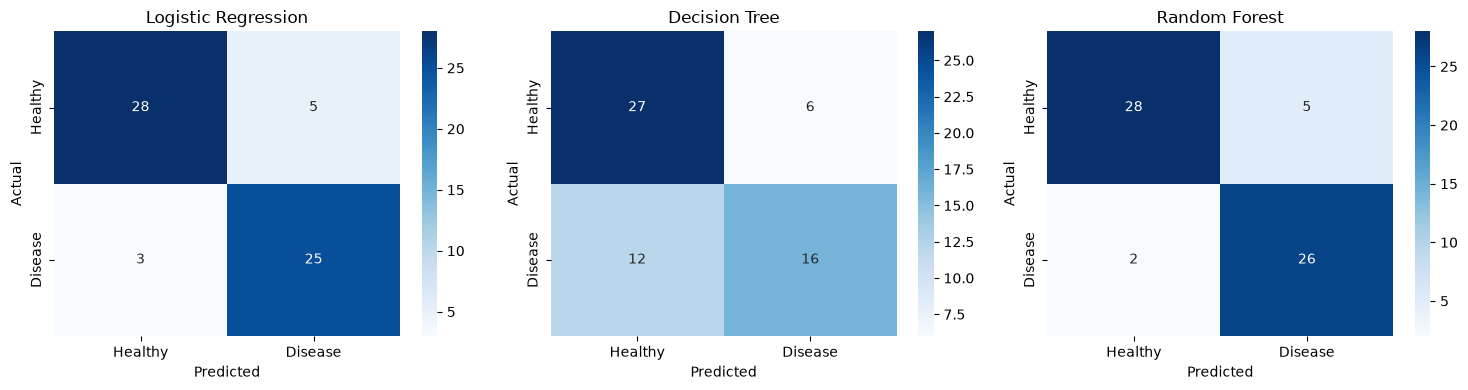

In [195]:
# Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes.flatten(), models.items()):
    y_pred = model.predict(X_test_final)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])

    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [196]:
display(results_df)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.868852,0.833333,0.892857,0.862069,0.962121
1,Decision Tree,0.704918,0.727273,0.571429,0.640000,0.802489
2,Random Forest,0.885246,0.838710,0.928571,0.881356,0.937229


**Note:** Decision Tree has performed very poorly as compared to the other two. It has a recall of 0.57 which means that it missed nearly half of the patients with heart disease. 

Random Forest beats Logistic Regression in every metric except ROC-AUC.

**Logistic Regression** has the highest ROC-AUC(96%), meaning it is more well-rounded than others. 

## 6. Feature Importance

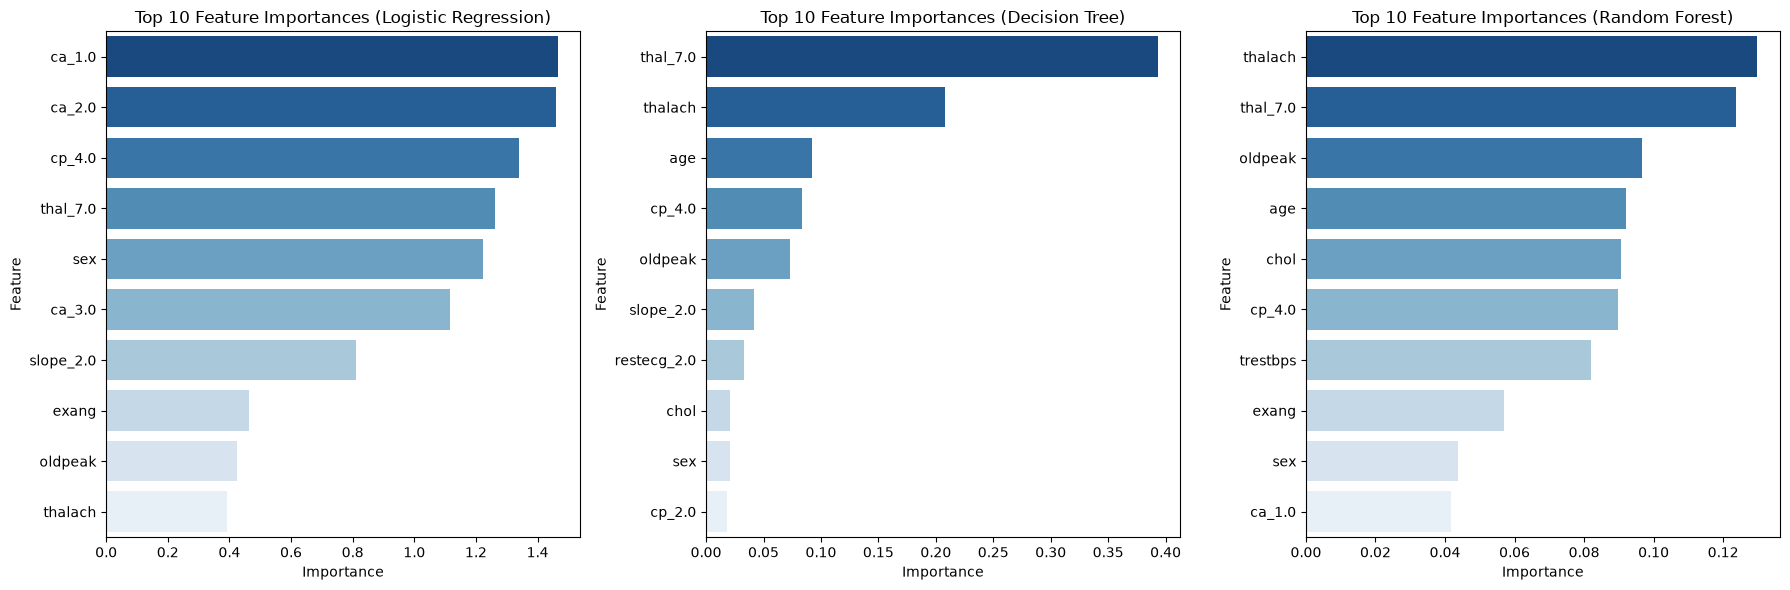

In [197]:

%matplotlib inline

def clean_name(name):
    return name.split('__', 1)[1] if '__' in name else name

all_features = [clean_name(n) for n in preprocessor.get_feature_names_out()]


fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 6))

for ax, (name, model) in zip(axes, models.items()):
    if hasattr(model, 'feature_importances_'):
        importances = pd.Series(model.feature_importances_, index=all_features)

    elif hasattr(model, 'coef_'):
        importances = pd.Series(model.coef_[0], index=all_features).abs()
    else:
        continue

    importances = importances.sort_values(ascending=False).head(10)

    sns.barplot(x=importances.values, y=importances.index, hue=importances.index, ax=ax, palette="Blues_r", legend=False)
    ax.set_title(f'Top 10 Feature Importances ({name})')
    ax.set_xlabel('Importance')
    ax.set_ylabel('Feature')

plt.tight_layout()
plt.show()
    
    


**Note:** **ca** dominates Logistic Regression but nowhere near the other two models. 

**thal** and **thalach** are the top 2 predictors in Decision Tree and Random Forest.

**cp** also makes a noticeable appearance in Logistic Regression and Decision Tree.


## 7. Permutation Importance

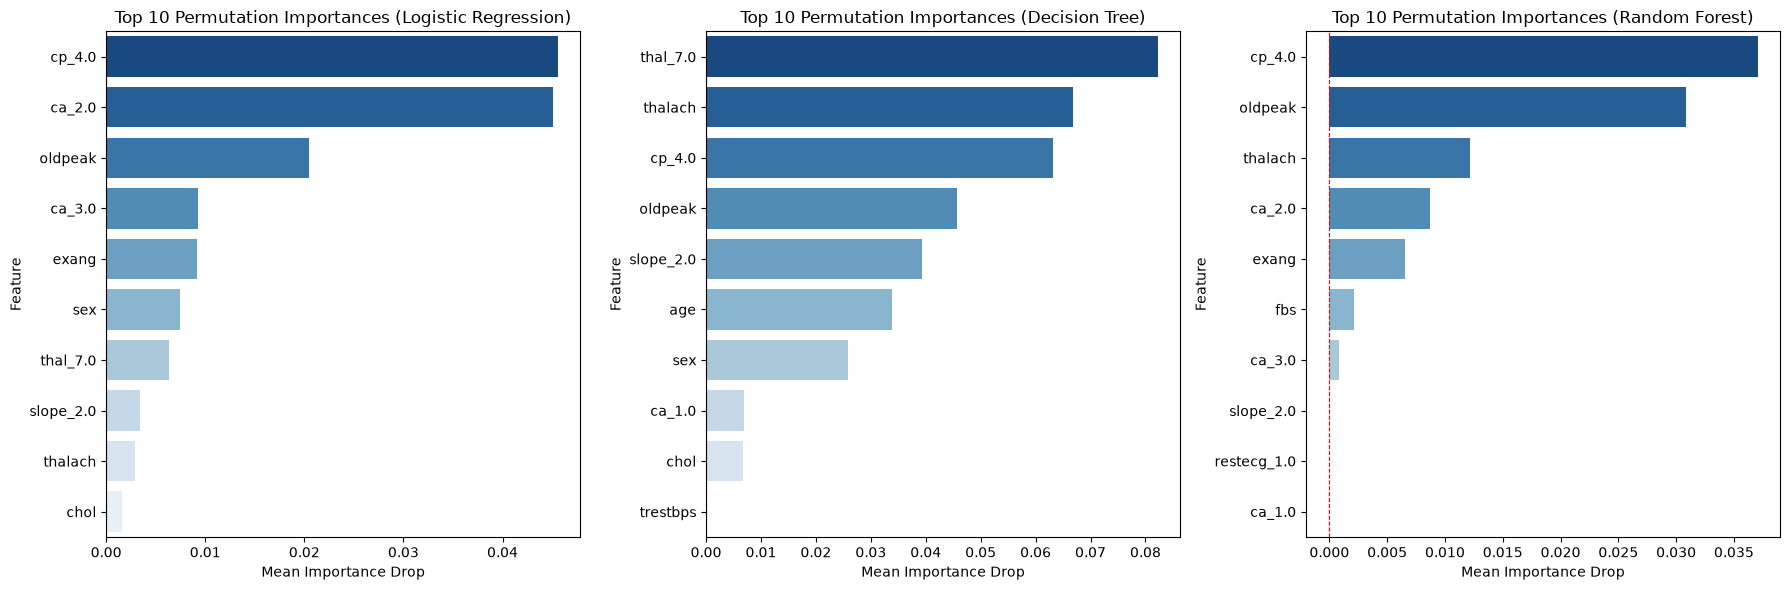

In [198]:
from sklearn.inspection import permutation_importance


fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 6))

for ax, (name, model) in zip(axes, models.items()):
    result = permutation_importance(
        model, X_test_final, y_test, scoring='roc_auc', n_repeats=10, random_state=42, n_jobs=1
    )
    importances = pd.Series(result.importances_mean, index=all_features, name='Importance').sort_values(ascending=False).head(10)
    importances.index.name='Feature'
    
    sns.barplot(x=importances.values, y=importances.index, hue=importances.index, ax=ax, palette='Blues_r', legend=False)

    ax.axvline(0, color='red', linestyle='--', linewidth=0.8)
    ax.set_title(f'Top 10 Permutation Importances ({name})')
    ax.set_xlabel('Mean Importance Drop')

plt.tight_layout()
plt.show()

**Note:** **cp** ranks consistently high across all three models.
**oldpeak** is also consistent across all three.

**thal** ranks highest in Decision Tree and **thalach** is consistent in Decision Tree and Random Forest.

**ca** is also noticeable in Logistic Regression and Random Forest.



## 8. Conclusion

- **Logistic Regression** is the strongest model for this dataset. Although Random Forest edges it out on Accuracy, Precision, Recall, and F1 at the default threshold, Logistic Regression has a higher and more consistent ROC-AUC — 96% on the held-out test set and 92% averaged across 5-fold cross-validation — meaning it ranks patient risk more reliably regardless of where the decision threshold is ultimately set, and its predictions are easier to interpret in a clinical context.
- **cp, thal, and thalach** rank consistently high across all three models, when combining both feature and permutation importances. Interestingly, thal ranks 2nd in Random Forest's feature importances list but is nowhere found in the model's permutation list, meaning that since thalach/oldpeak/cp carry overlapping signal, shuffling thal alone doesn't hurt predictions much. **ca** dominates Logistic Regression's coefficients specifically, but is largely absent from Decision Tree's top features.
- Future work includes testing on larger clinical cohorts and tuning prediction thresholds to further reduce false negative diagnostic rates.
  